# A Framework for Leveraging LLMs for Scene Analysis and Cognitive Processing

In [20]:
import os
HOME = os.getcwd()

os.chdir(HOME)
print(HOME)

d:\home\Documents\Github\human_patterns_exploration


In [21]:
from src.utils.sam_utils import download_model_weight, download_model_config

INSTALL = False
if INSTALL:
    download_model_weight("sam2.1_hiera_large.pt")
    download_model_config("sam2.1_hiera_l.yaml")
    !pip install sam2


In [22]:
import os
import pandas as pd
from src.core.FixationTask import FixationTask
from src.core.Participant import Participant
from src.core.ImageData import ImageData
from src.core.Mask import Mask
from src.models.MaskGenerator import SAM2

from src.prompts.gaze_prompts import *

In [23]:
font_color =  "yellow"          
COLOR_CODE_1 = "fixation_scarletred_meddark"
COLOR_CODE_2 = "aluminium"
COLOR_CODE_3 = "yellow"

In [24]:

DATA_DIR = os.path.join(".", "data", "experiments")
IMAGE_DIR = os.path.join(".", "data", "images")
RESULTS_DIR = os.path.join(".", "outputs")

SAM_CONFIG = os.path.join(".", "configs", "sam2.1", "sam2.1_hiera_l.yaml")
SAM_MODEL =  os.path.join(".", "checkpoints", "sam2.1_hiera_large.pt")

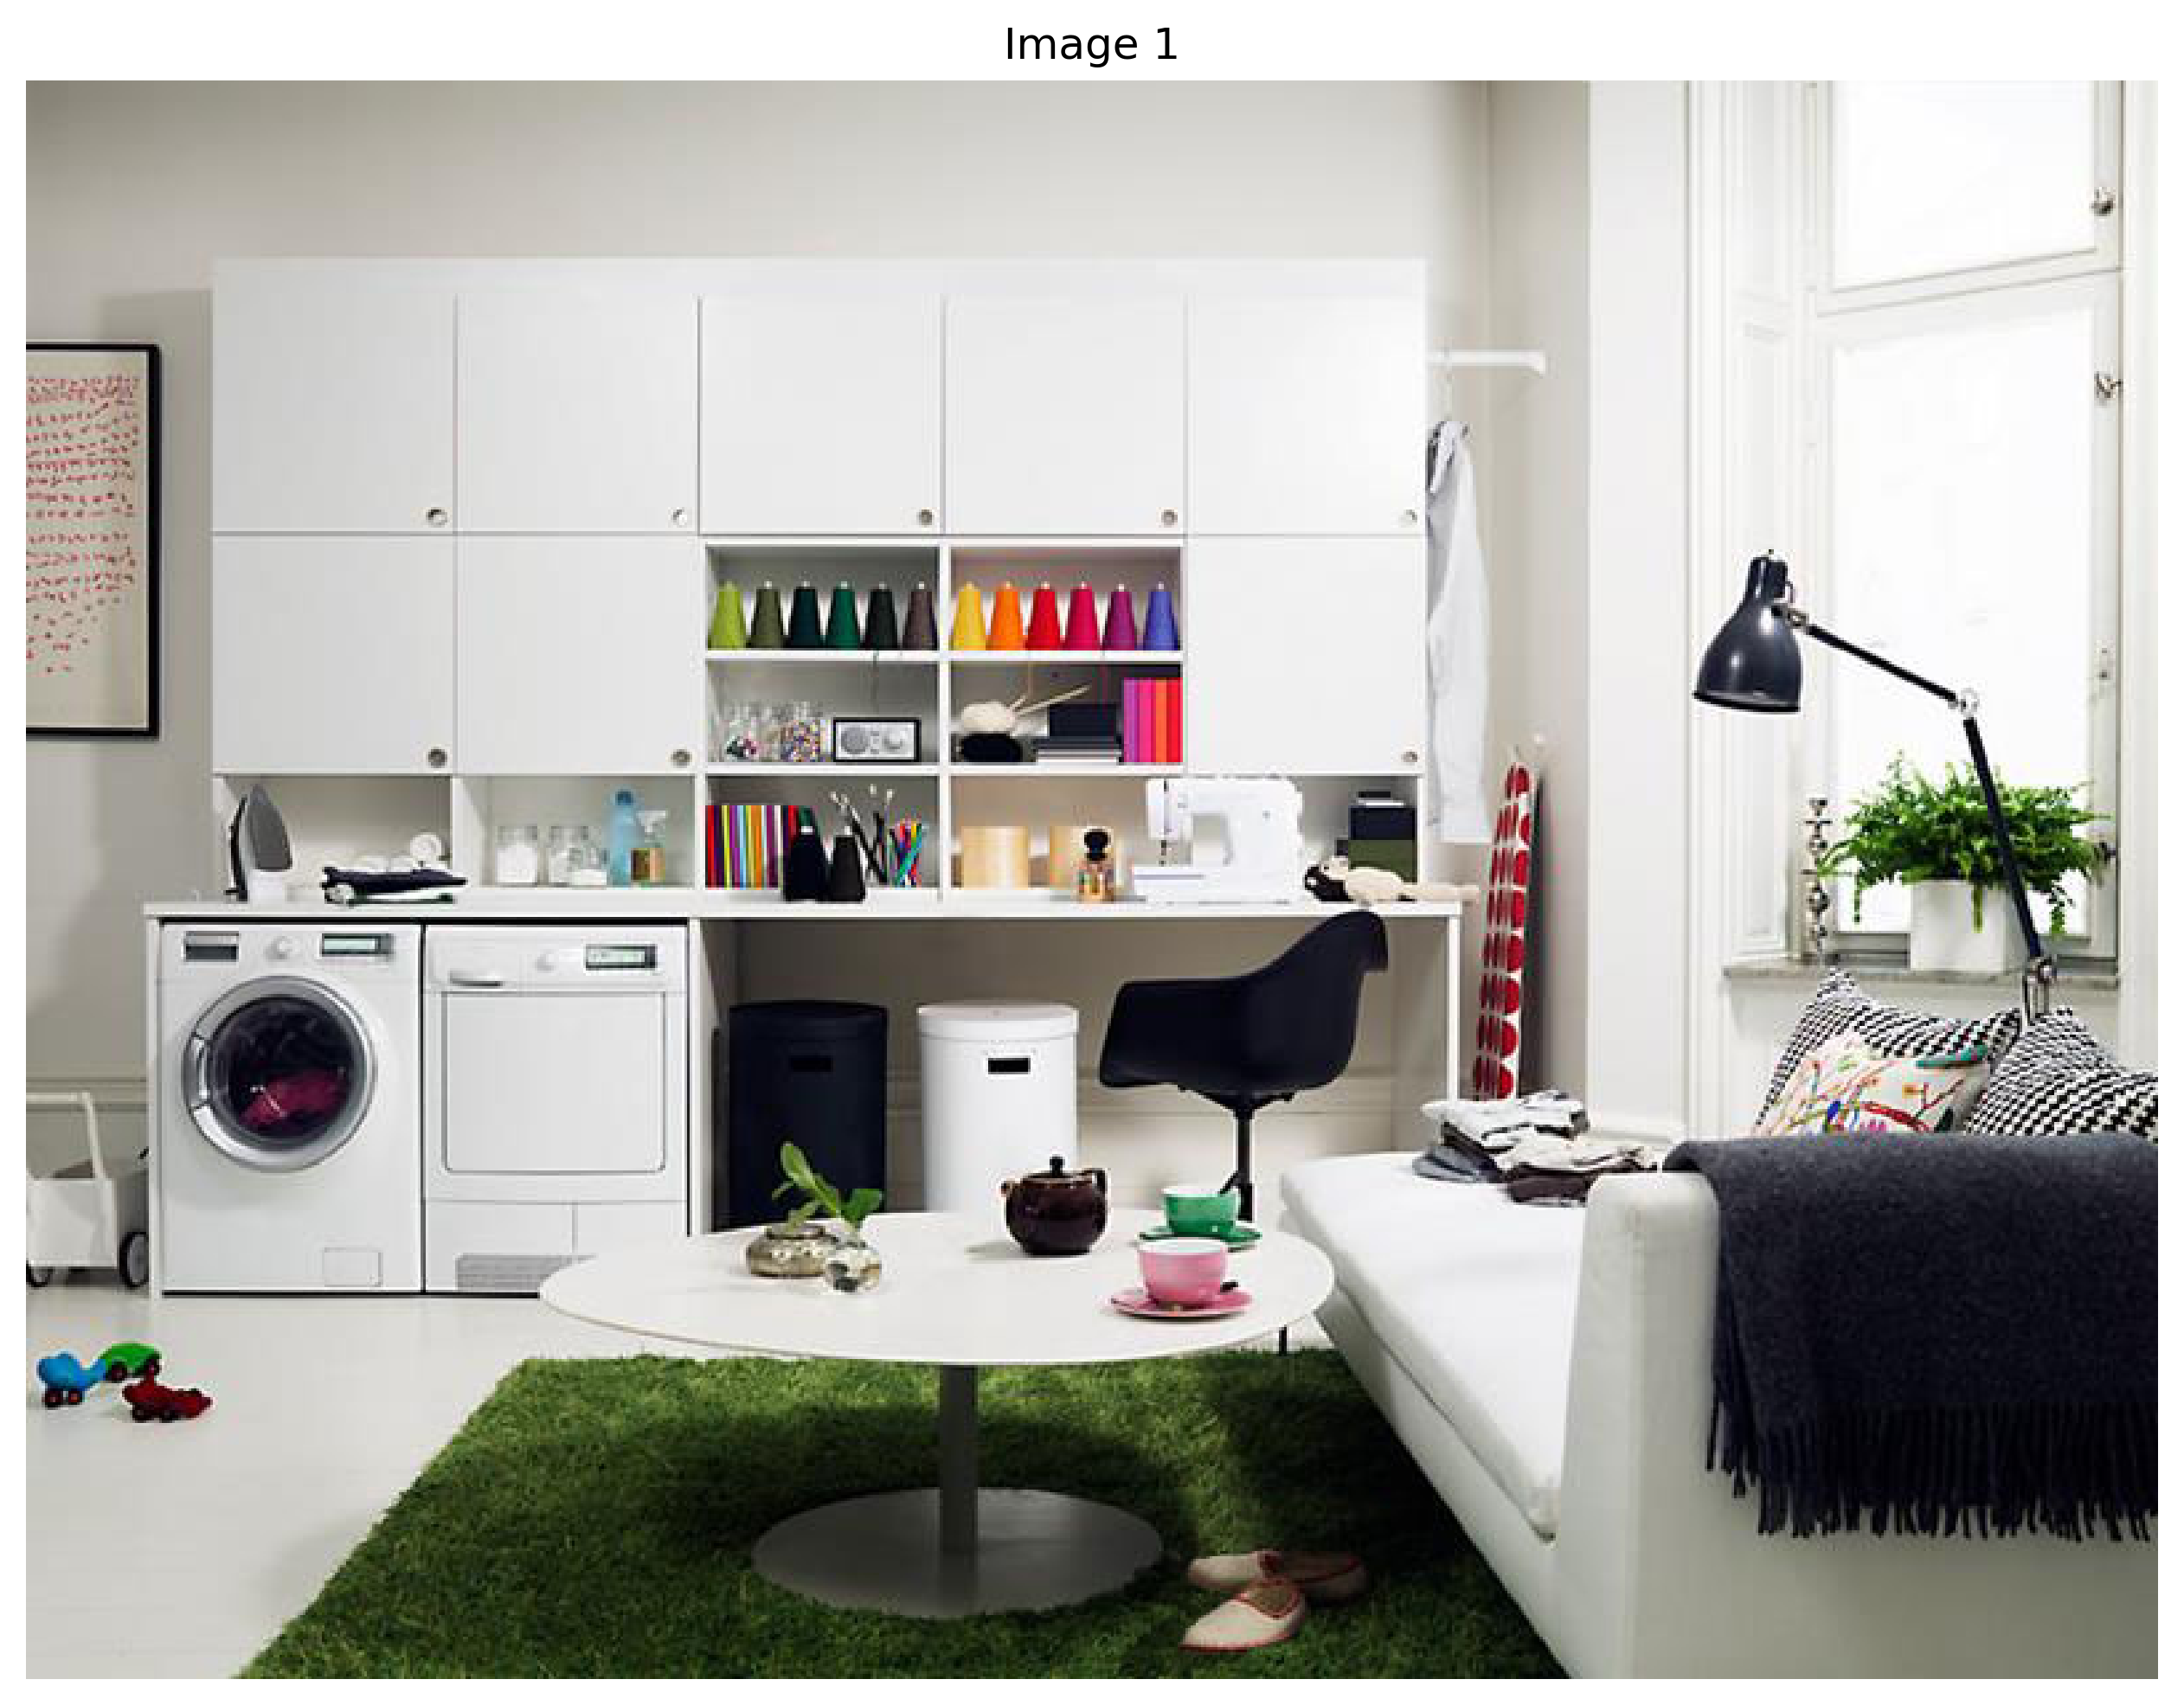

In [25]:
IMG_ID = 1
imgpath = os.path.join(IMAGE_DIR, f"{IMG_ID}exp.jpg")
imageData = ImageData(imgpath)
imageData.show()

## Testing Gaze Points


In [26]:
datapath =  os.path.join("data", "experiments", "XSQ_Expt1_Data_2.csv")
data = pd.read_csv(datapath)

In [27]:
IMG_ID = 1
part_ID = int(data[data.ItemNum == IMG_ID].ParticipantID.unique()[0])
participant =  Participant(part_ID)
print("Participant ID:", part_ID)

imgpath = os.path.join(IMAGE_DIR, f"{IMG_ID}exp.jpg")
print("Image Path:", imgpath)

imageData = ImageData(imgpath, target = [430, 510, 545, 595], img_type = "exp")

CONDITION_ID = 1
GROUP_ID = 1
task = FixationTask(participant, imageData, data, condition = CONDITION_ID, group = GROUP_ID, rows_per_second=1)

Participant ID: 2
Image Path: .\data\images\1exp.jpg
Participant data before center bias removal:  4
Participant data after center bias removal:  3


In [28]:
task_data = task.data.copy()

In [29]:
prompt_0 = task_data.iloc[0]
prompt_1 = task_data.iloc[1]
prompt_2 = task_data.iloc[2]

### Point Gaze Prompt

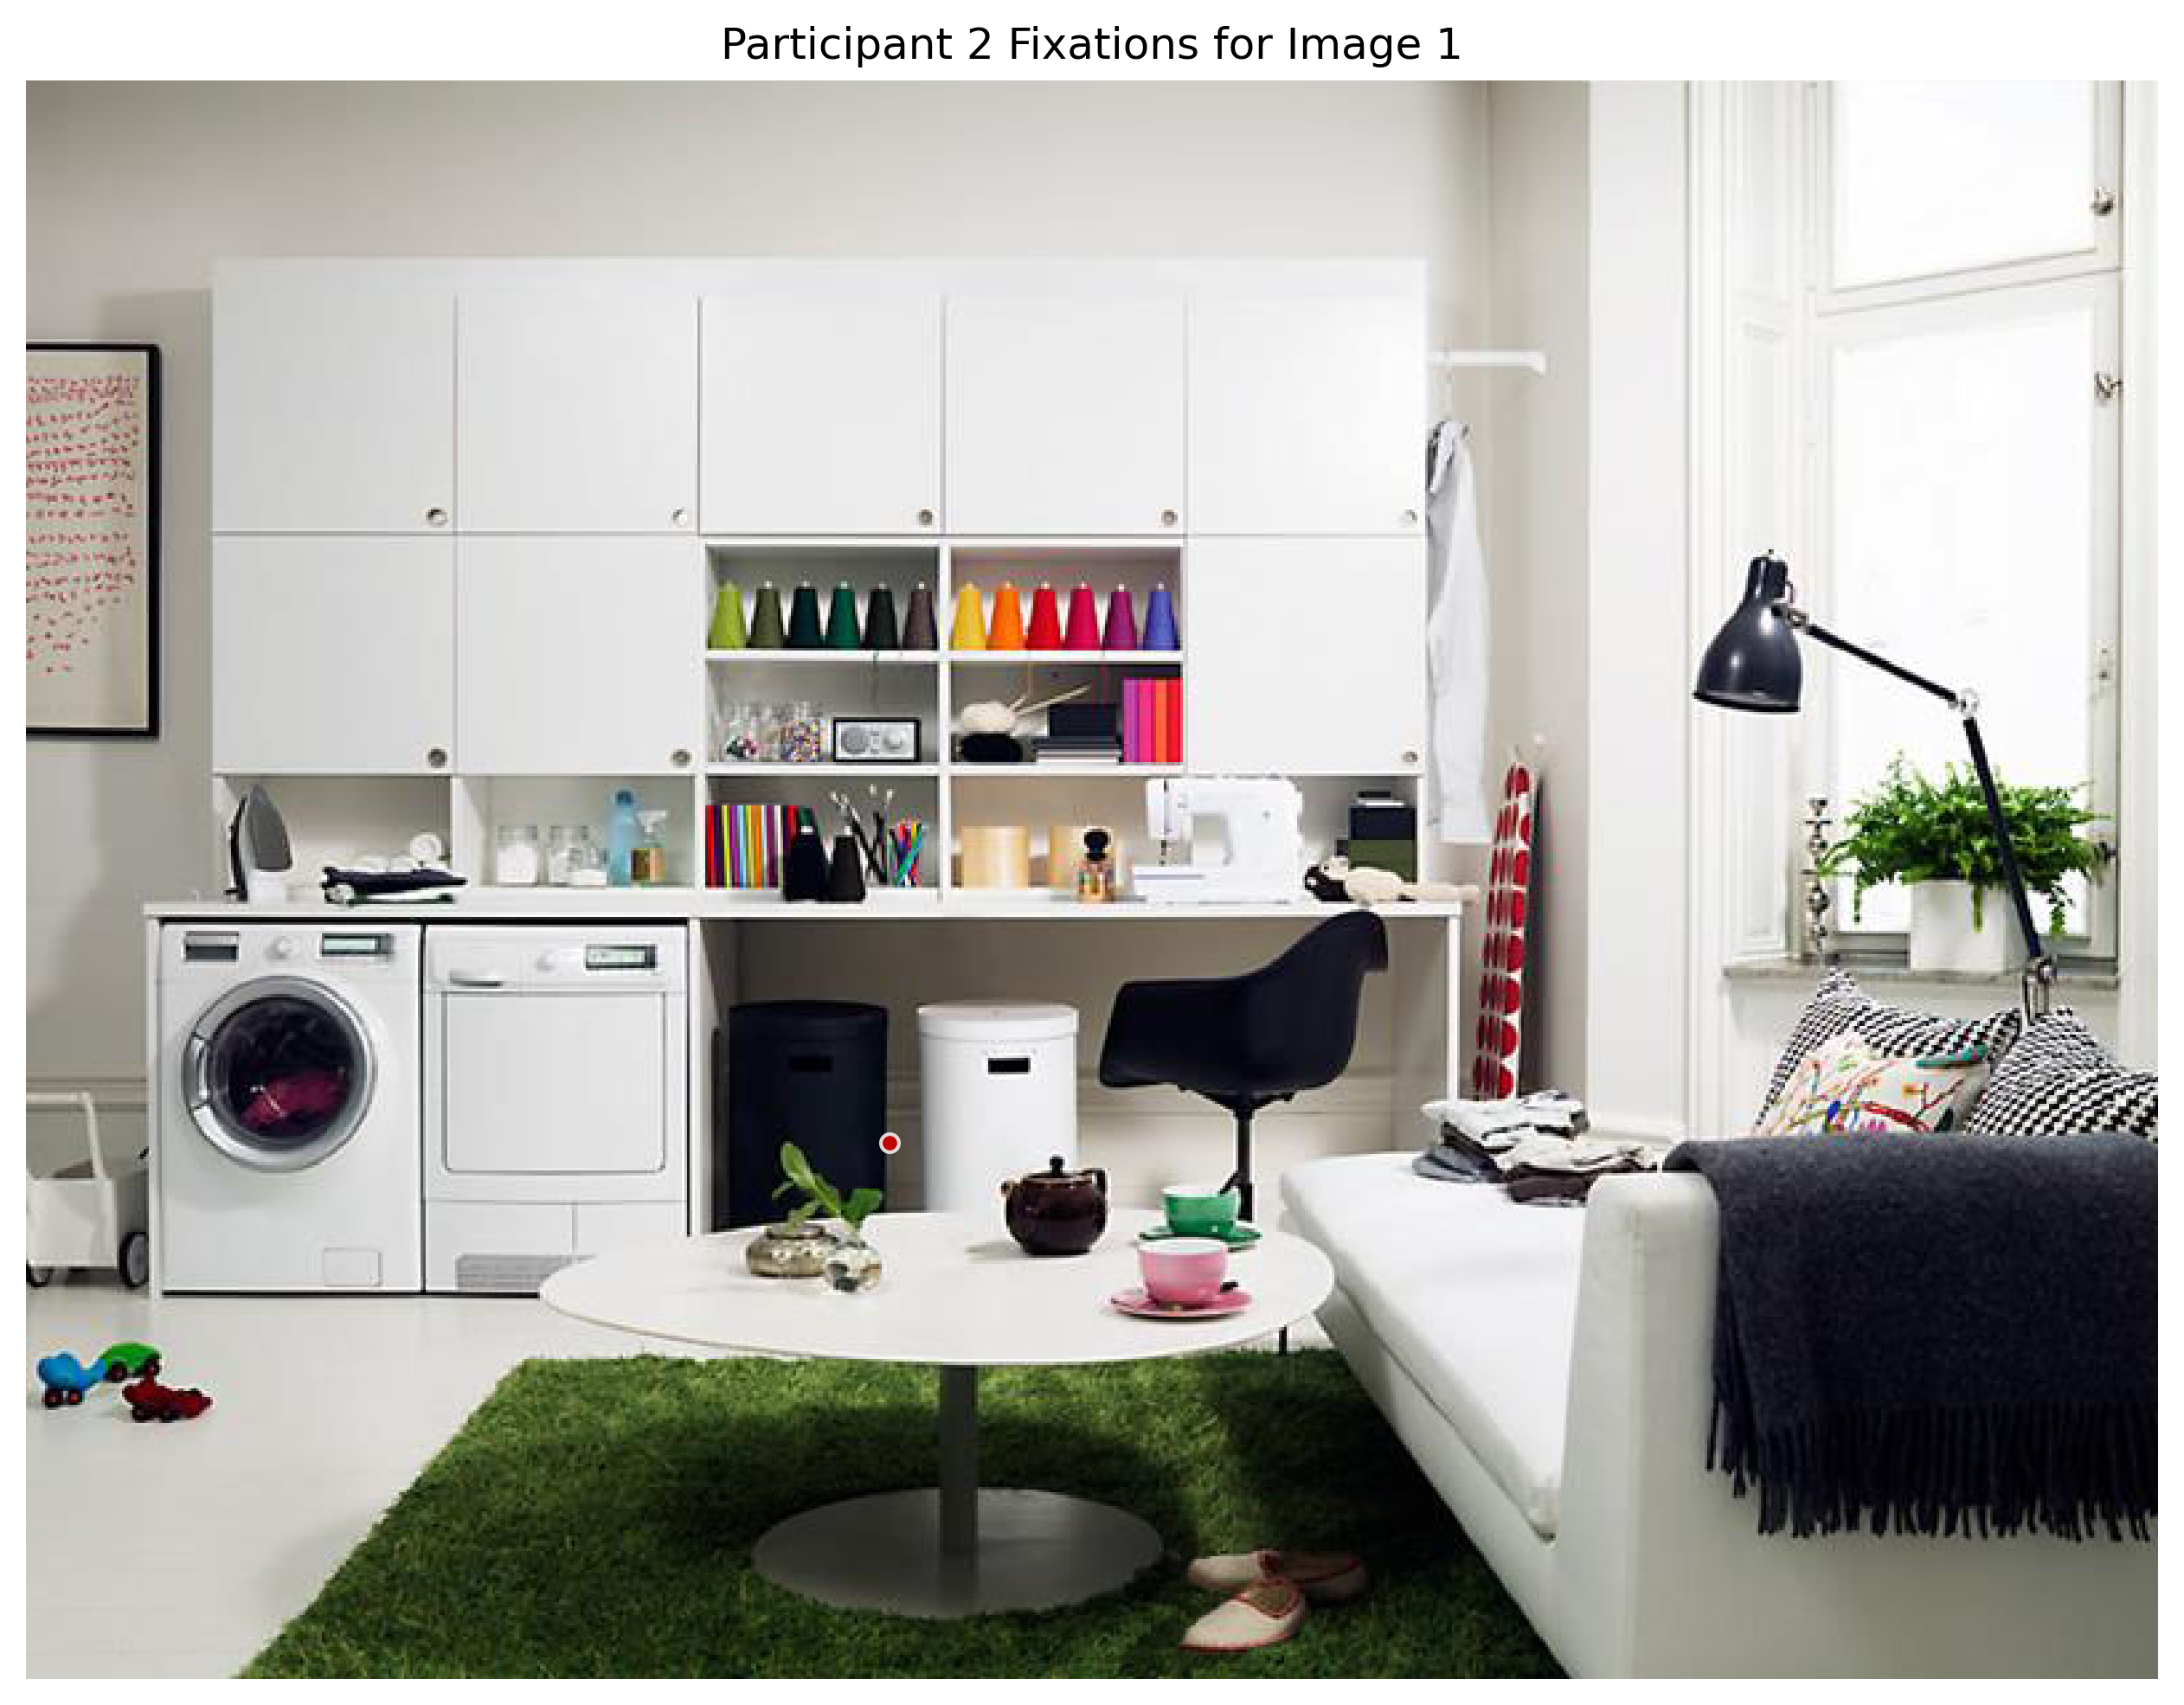

In [30]:
aug_task_data = sample_points_point(prompt_0)
task.draw_fixations( df = aug_task_data, fix_color=COLOR_CODE_1, fix_edge_color=COLOR_CODE_2, alpha=0.9, size = 25 )

### Triangle Gaze Prompt

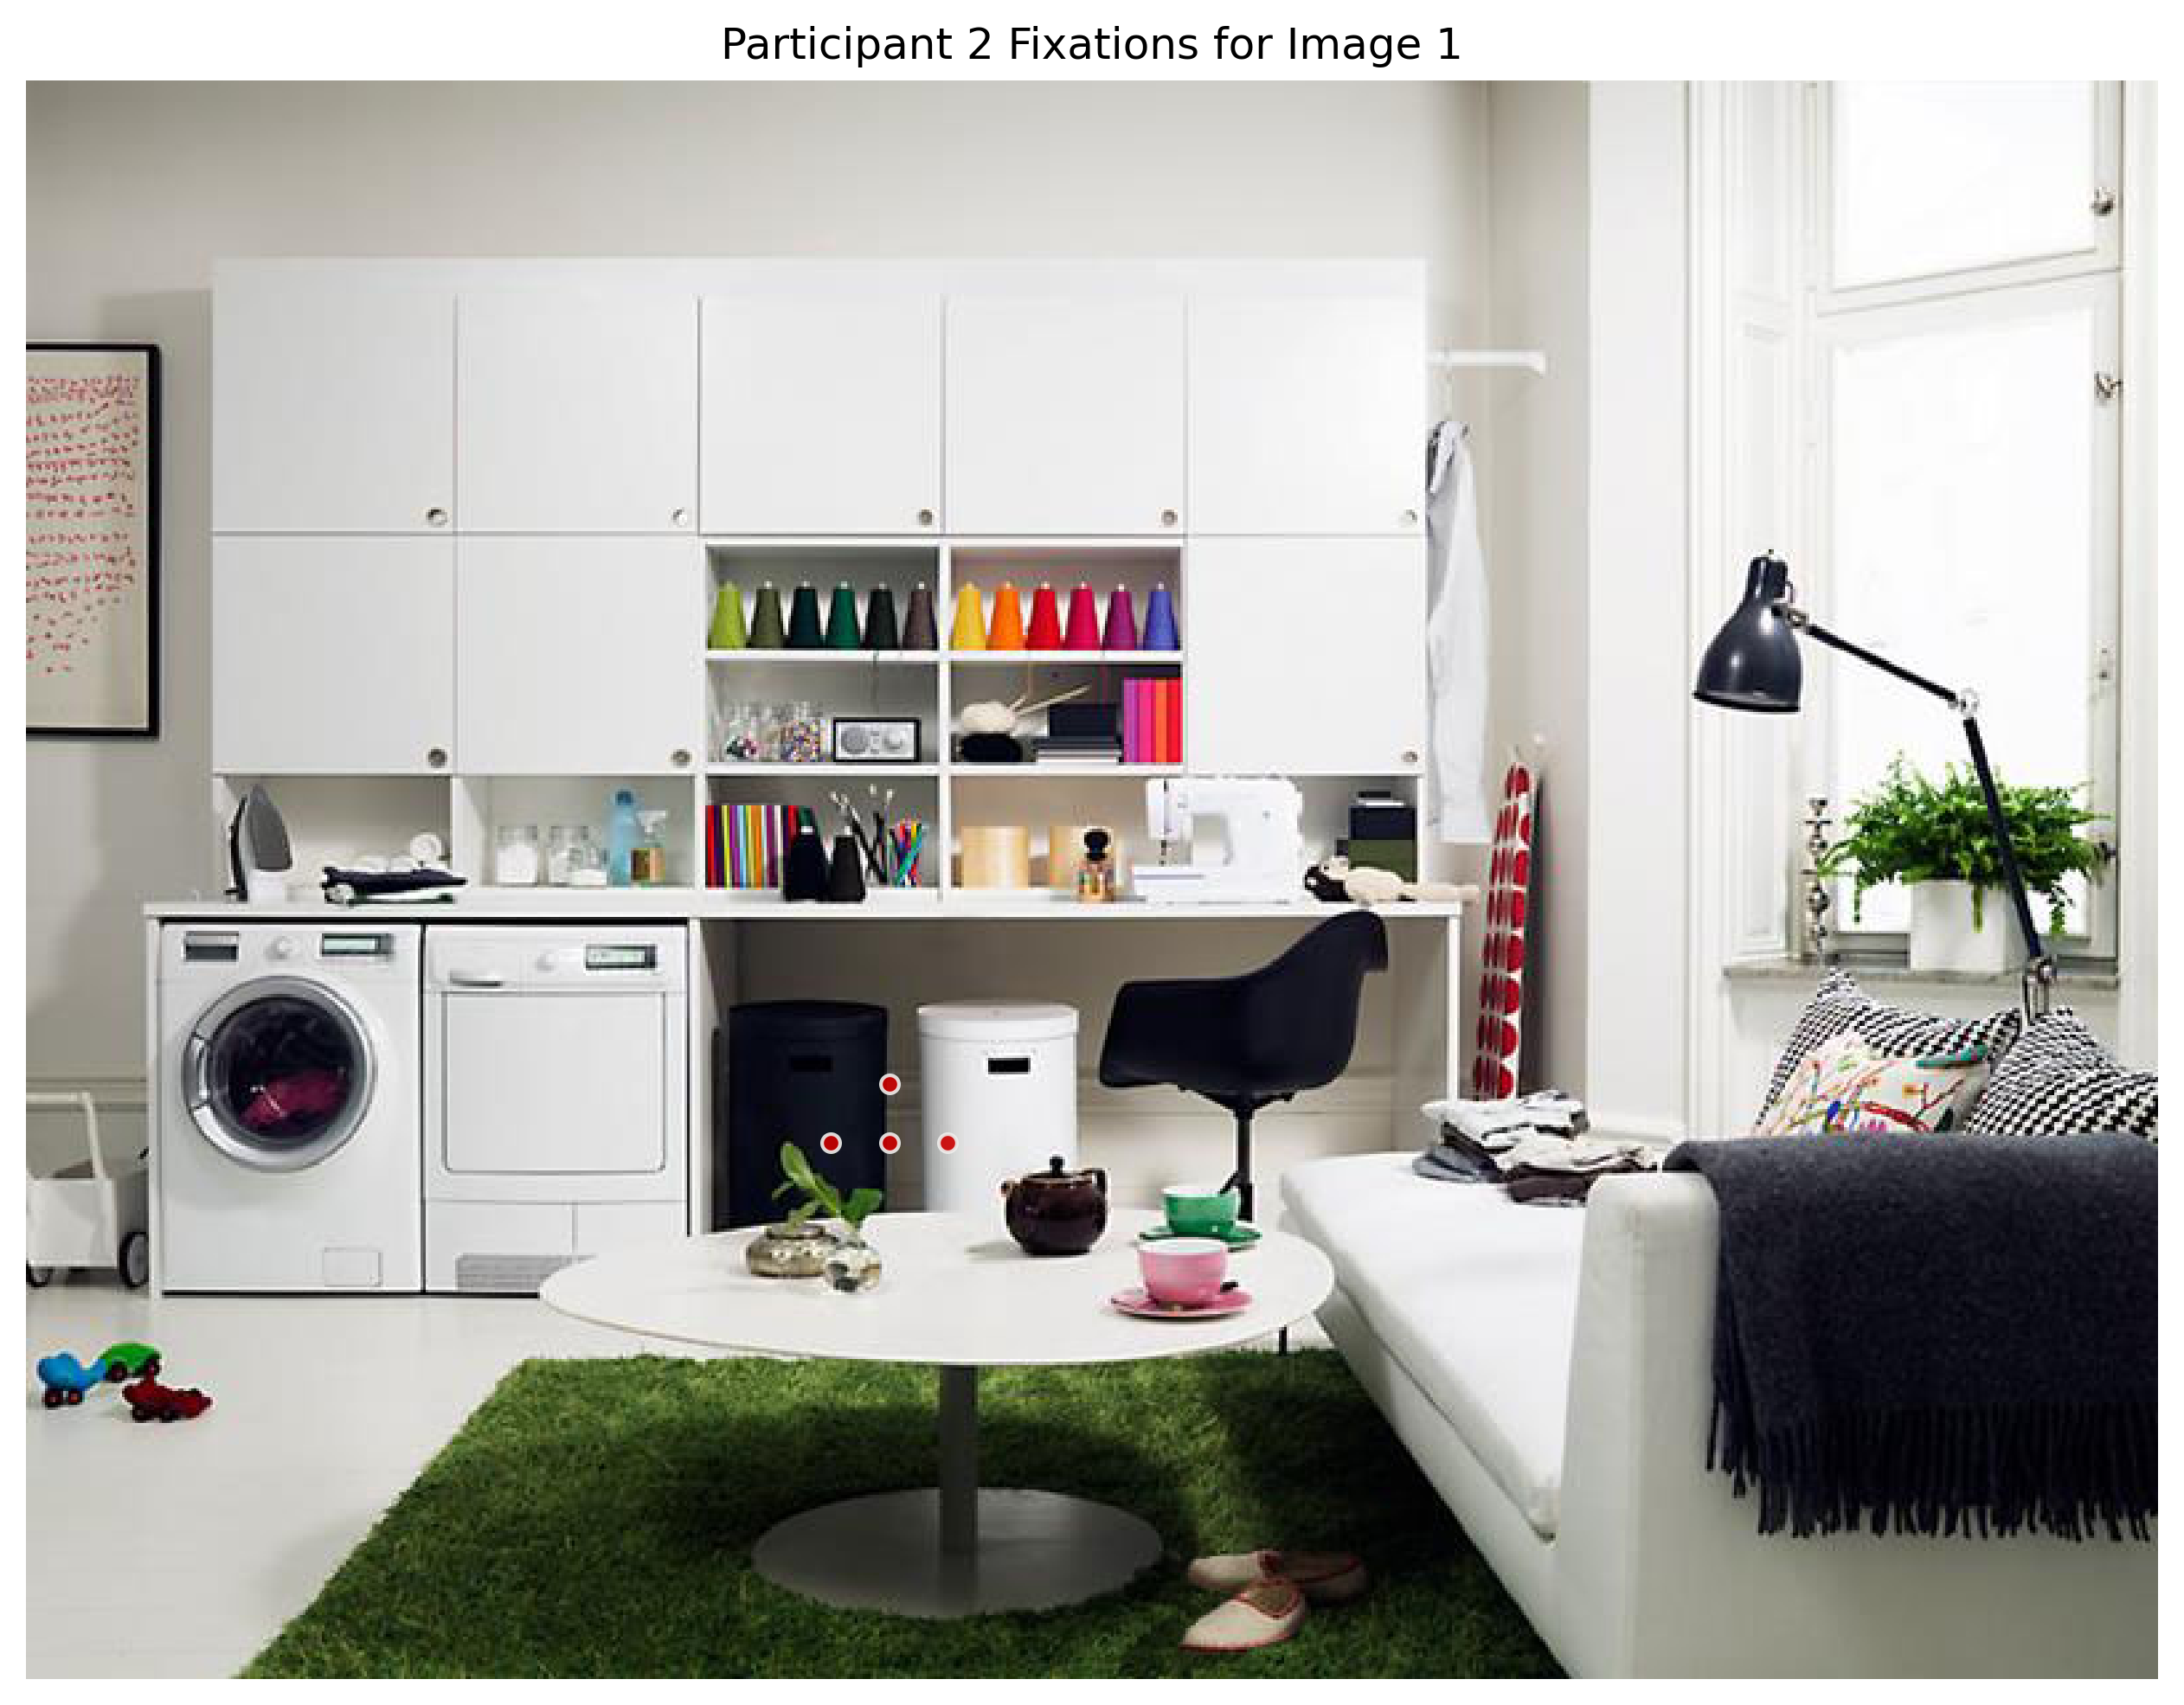

In [31]:
aug_task_data = sample_points_triangle(prompt_0)
task.draw_fixations( df = aug_task_data, fix_color=COLOR_CODE_1, fix_edge_color=COLOR_CODE_2, alpha=0.9, size = 25 )

### Cross Gaze Prompt

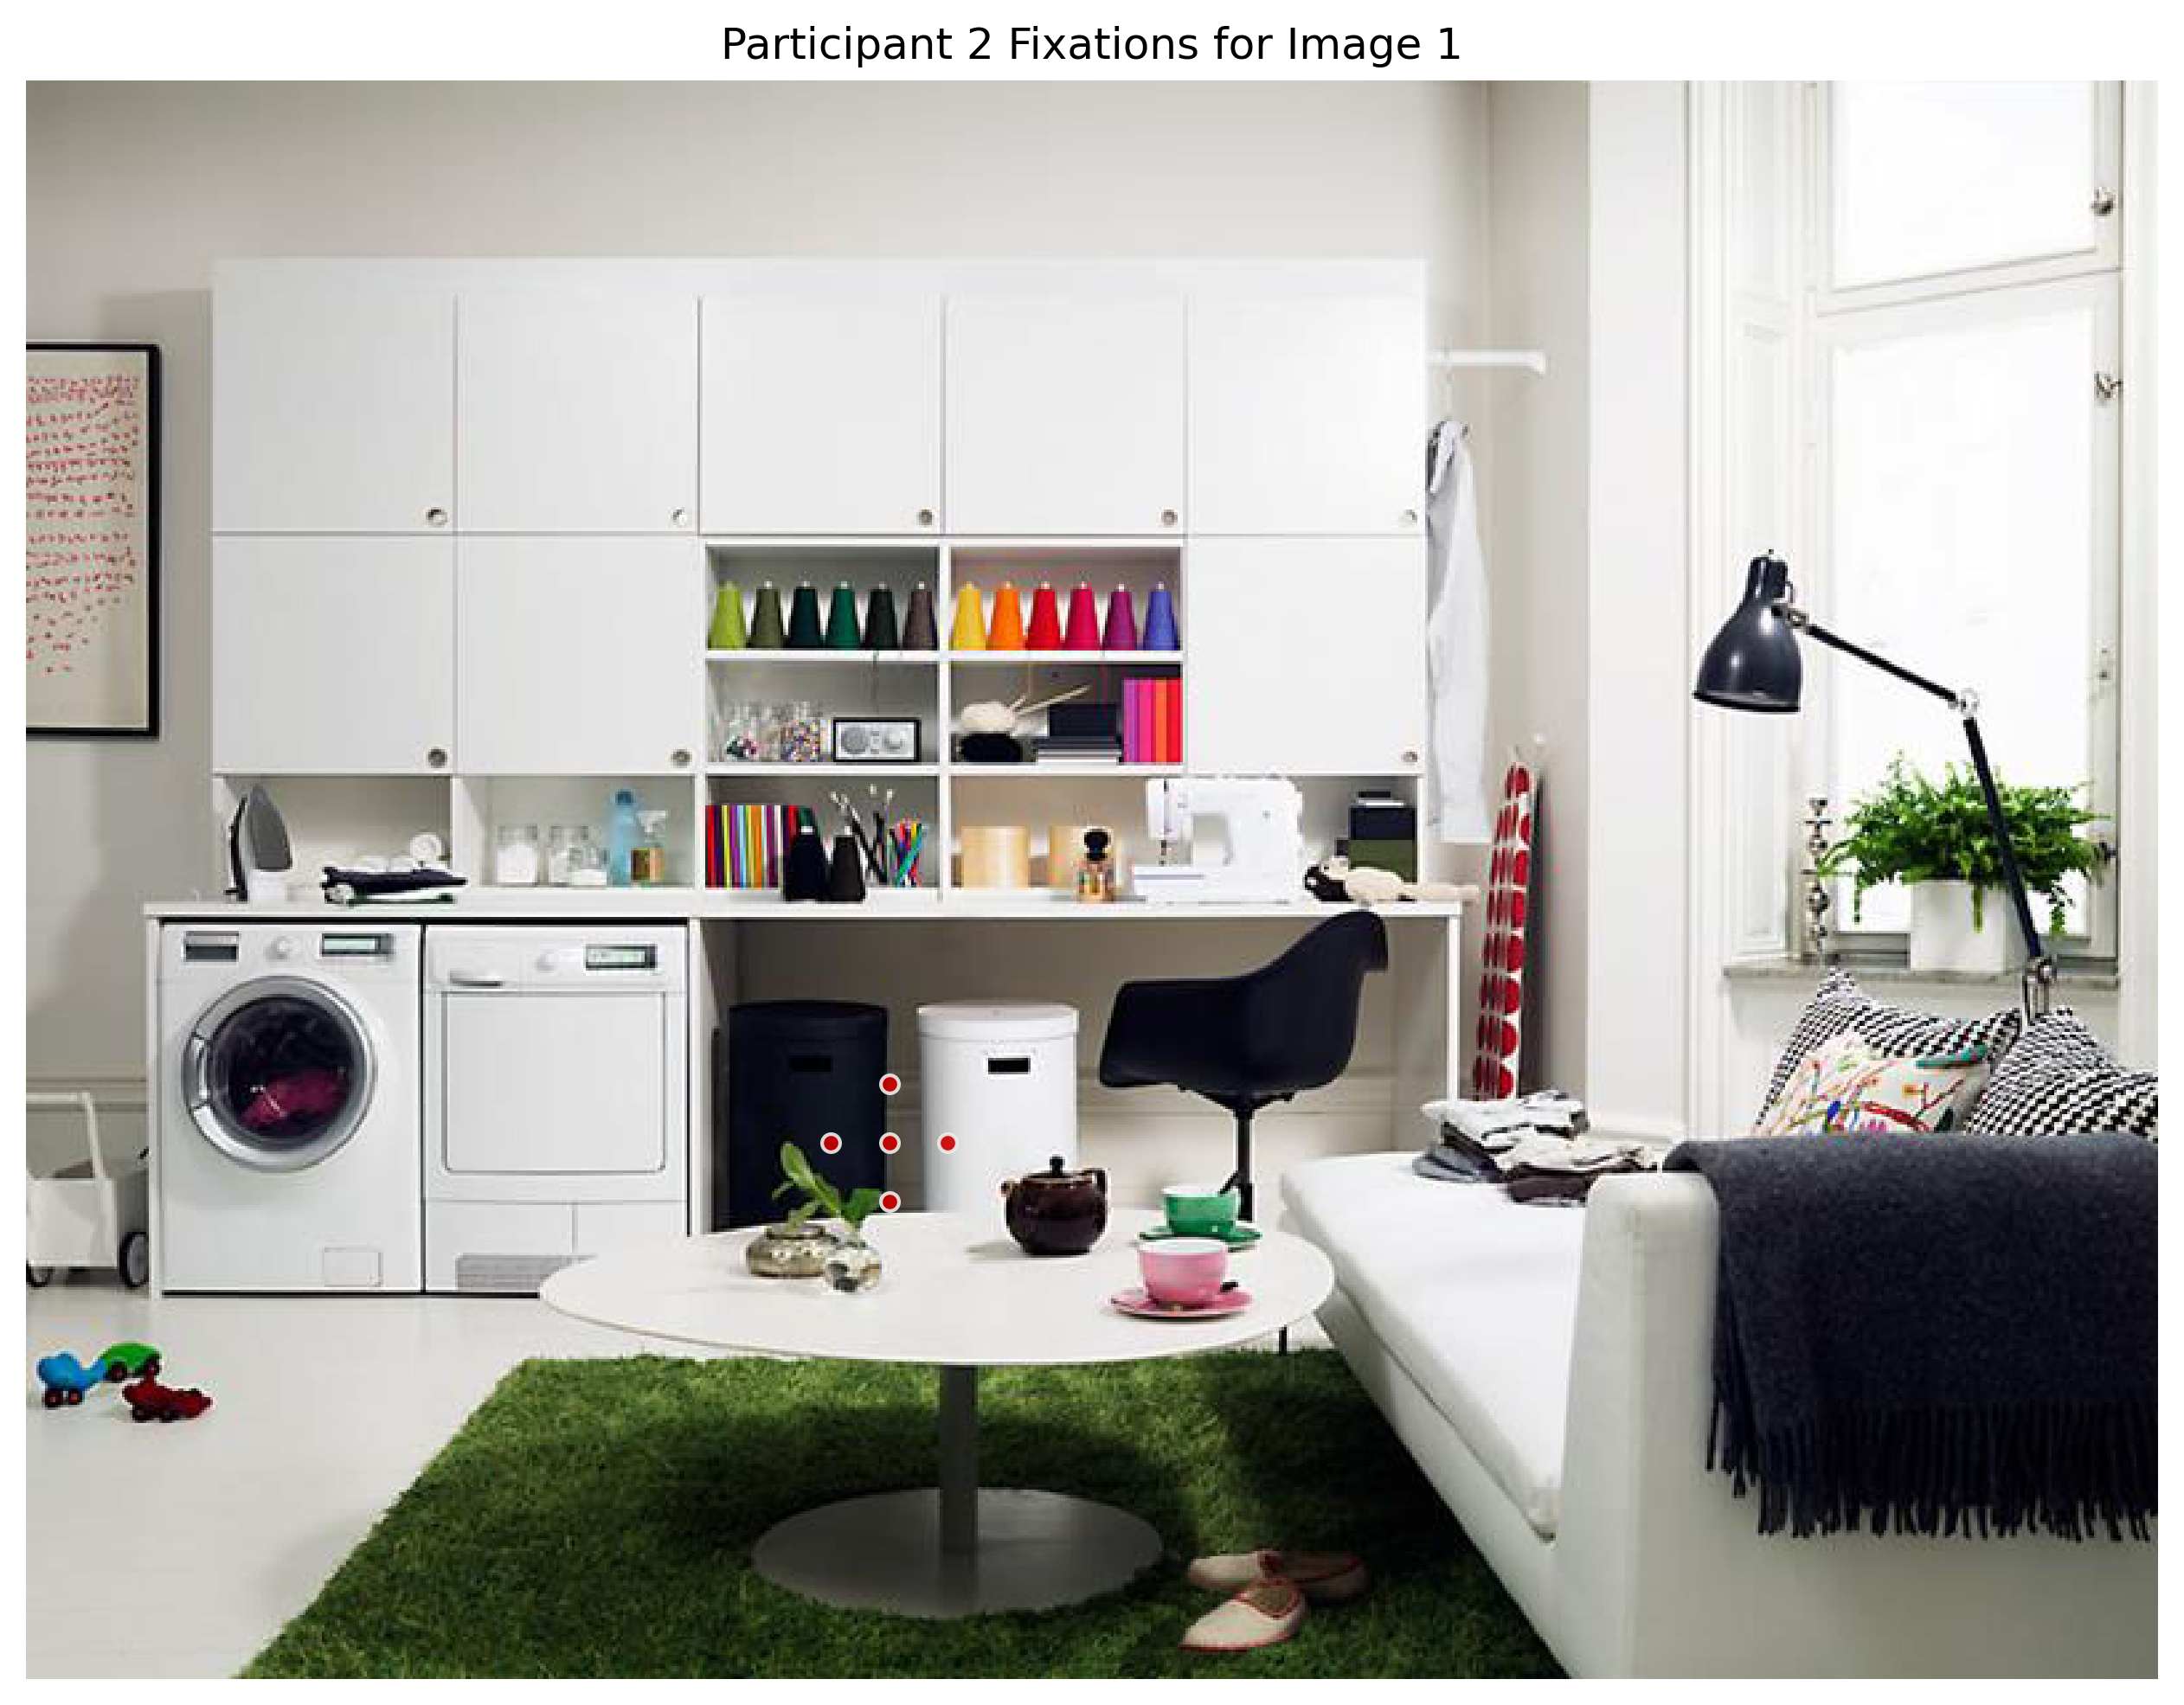

In [32]:
aug_task_data = sample_points_cross(prompt_0)
task.draw_fixations( df = aug_task_data, fix_color=COLOR_CODE_1, fix_edge_color=COLOR_CODE_2, alpha=0.9, size = 25 )

### Circle Gaze Prompt

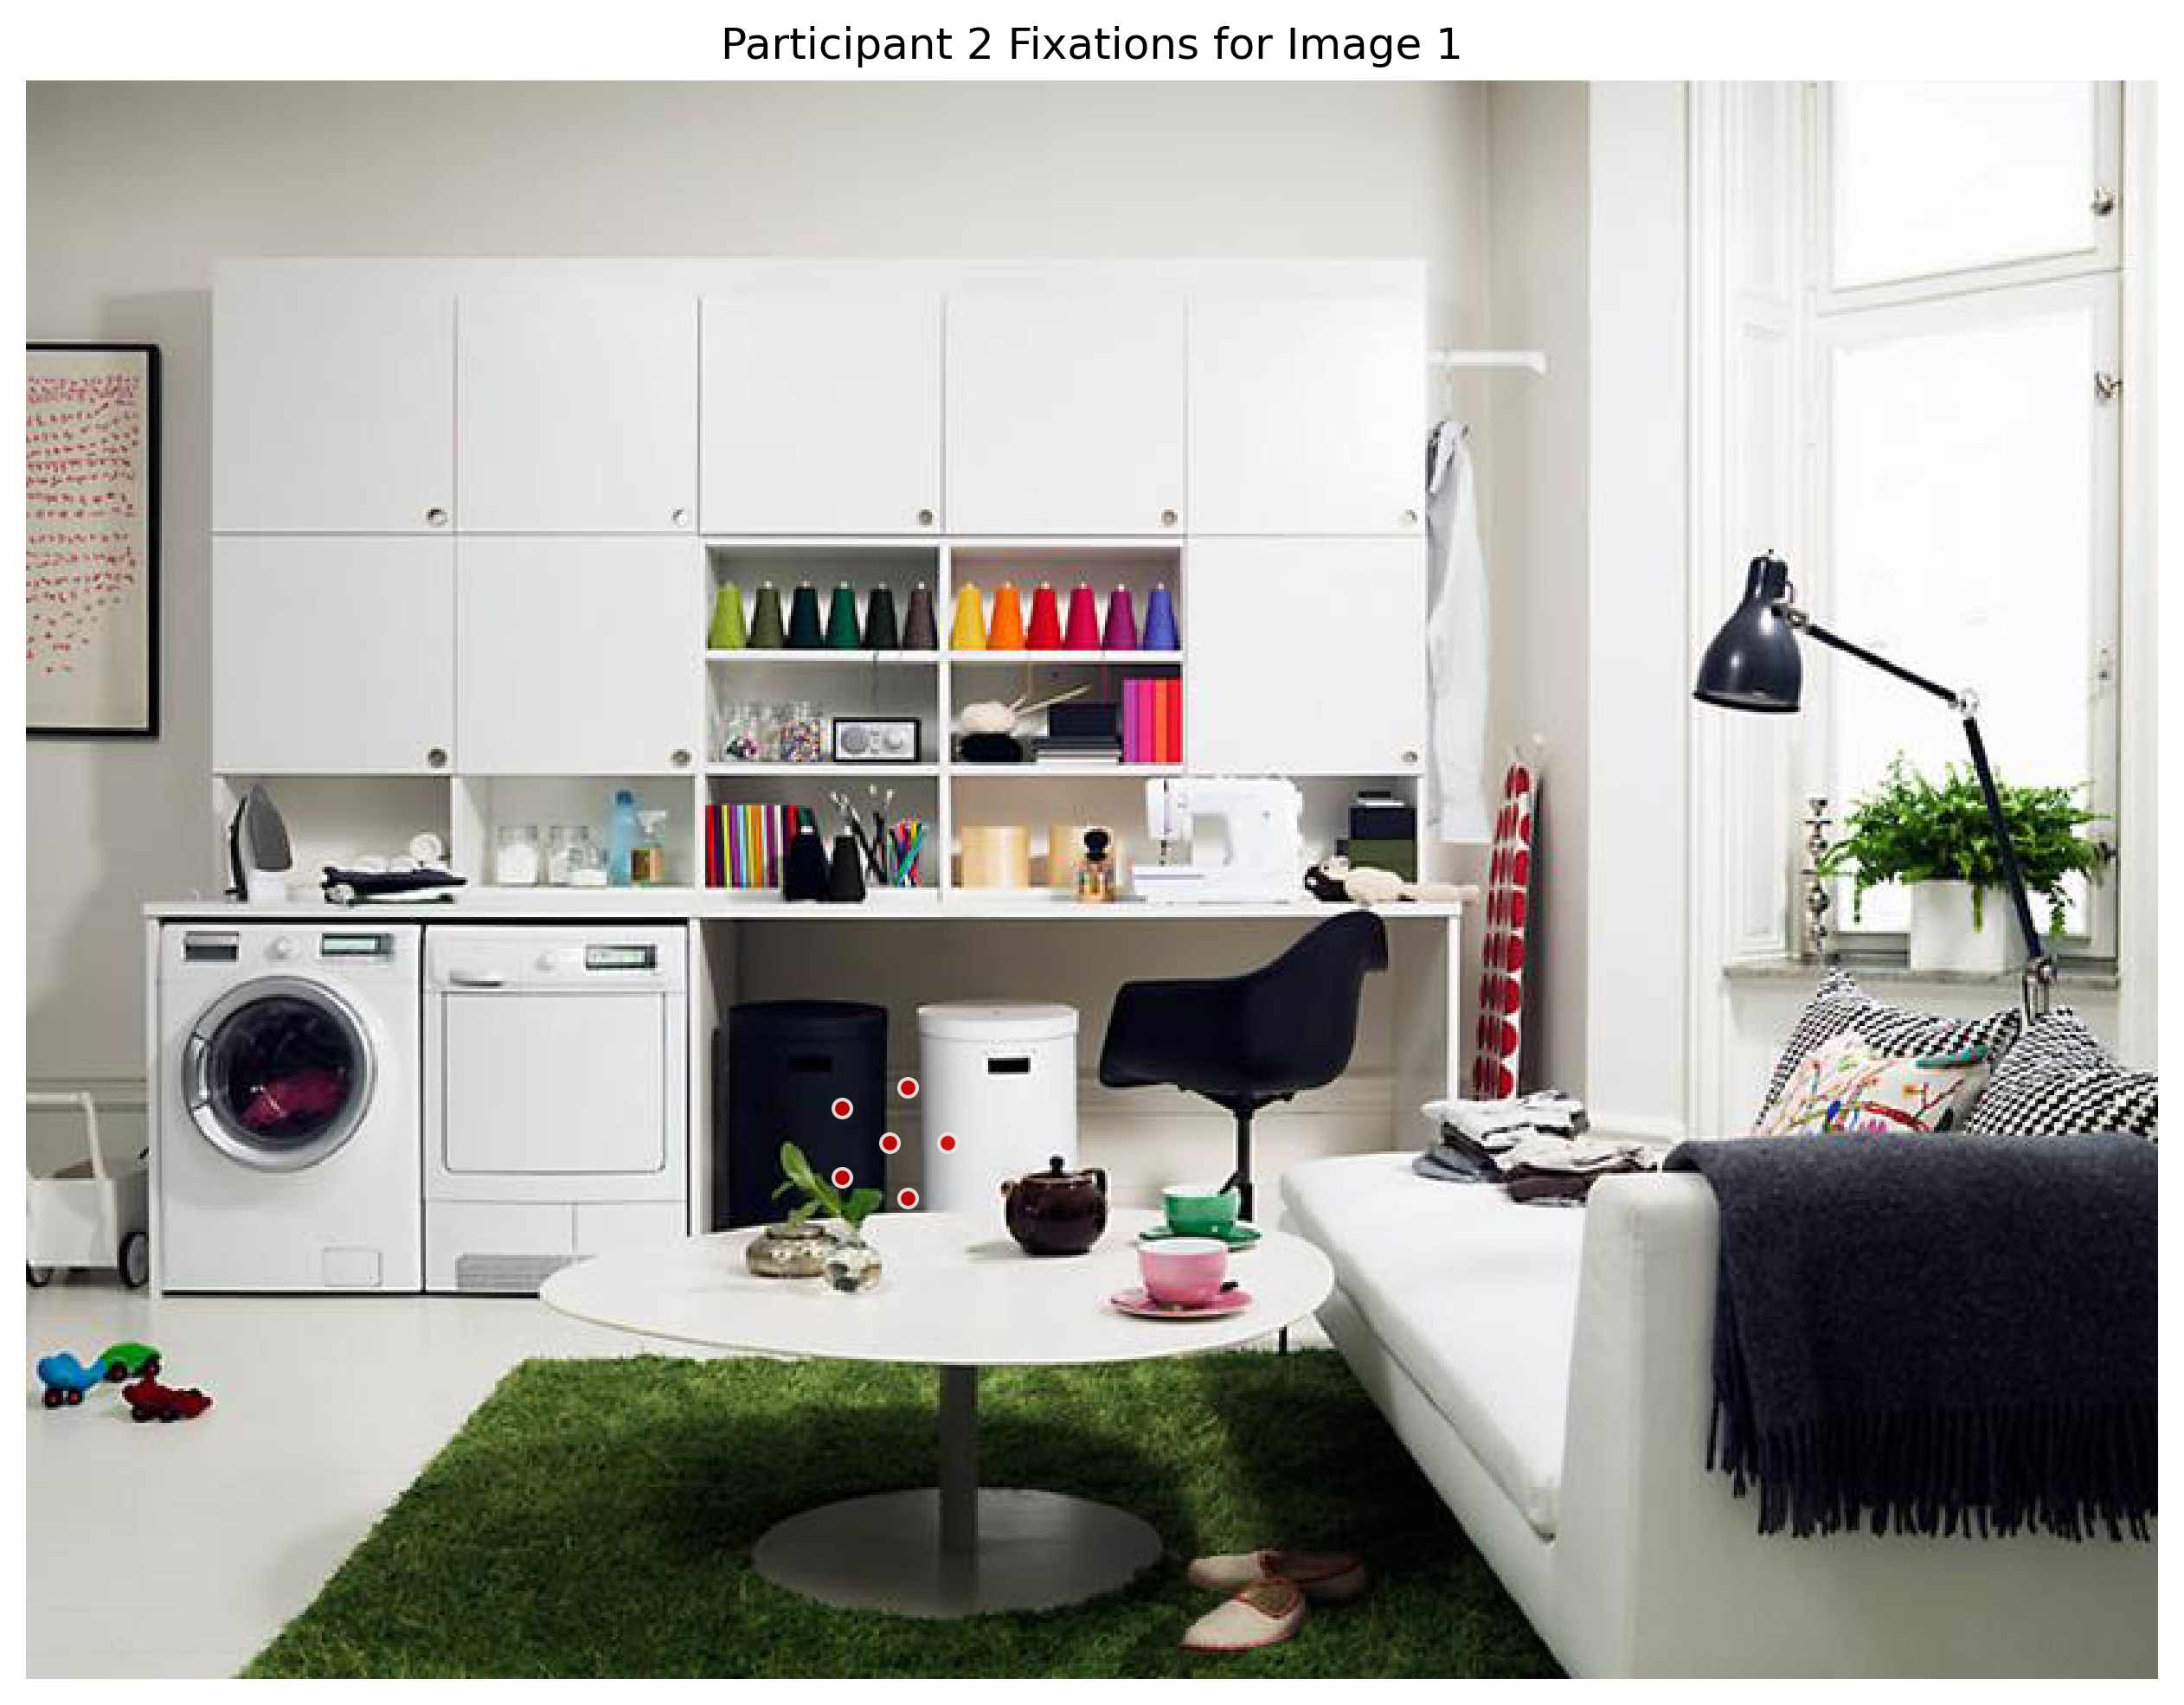

In [33]:
aug_task_data = sample_points_circle(prompt_0, N = 5)
task.draw_fixations( df = aug_task_data, fix_color=COLOR_CODE_1, fix_edge_color=COLOR_CODE_2, alpha=0.9, size = 25 )

## Testing Mask Segmentation and Labeling

Generate the description for this scene

In [34]:
from src.models.LLM import LLM, OpenAI, Ollama
from src.models.Framework import SceneUnderstandingFramework
from src.utils.llm_utils import create_llm_instance

In [35]:
print(f"Processing image ID: {IMG_ID}")
print(f"\tGenerating general scene description...")
llm = create_llm_instance("openai", "gpt-4o", temperature = 0.1)  # the lower the temperature, the more deterministic is the output
framework = SceneUnderstandingFramework(llm)
scene_description = framework.analyze_scene(imageData)
print(scene_description)

Processing image ID: 1
	Generating general scene description...
Scene description completed in 17.18 seconds
1. **Scene Overview**: 
   - The image depicts a multifunctional room combining a laundry area, workspace, and living space. The setting appears to be a modern, organized home environment.

2. **Identified Objects**:
   - **Laundry Appliances**: A washing machine and dryer are located on the left side.
   - **Cabinets**: White cabinets are mounted on the wall above the workspace.
   - **Shelves**: Open shelves with colorful cones of thread or yarn, books, and decorative items are situated in the center.
   - **Desk**: Below the shelves, there is a desk with various items including a sewing machine, lamp, and office supplies.
   - **Chairs**: A black office chair is positioned at the desk.
   - **Table**: A round white coffee table is in the foreground.
   - **Sofa**: A white sofa with cushions and a dark throw is on the right side.
   - **Lamp**: A black floor lamp is near the s

In [36]:
mask_gen = SAM2(sam_model_path = SAM_MODEL, sam_model_config = SAM_CONFIG, task = task)

cpu


Processing prompt type: point
Processing prompt type: circle
Processing prompt type: triangle
Processing prompt type: cross
Best mask found with prompt type: point, score: 0.8915


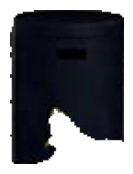

Mask labeling completed in 0.93 seconds
Mask labeling completed in 0.64 seconds
Mask labeling completed in 1.63 seconds
Mask labeling completed in 1.41 seconds
Mask labeling completed in 0.72 seconds
Mask labeling completed in 0.92 seconds
Mask labeling completed in 1.14 seconds
Mask labeling completed in 0.86 seconds
Mask labeling completed in 1.74 seconds
Mask labeling completed in 0.76 seconds


['hamper',
 'hamper',
 'hamper',
 'hamper',
 'hamper',
 'hamper',
 'hamper',
 'hamper',
 'hamper',
 'hamper']

In [37]:
mask = mask_gen.compute_masks_with_prompt(0,prompt_0, output_path = os.path.join(RESULTS_DIR, "Masks"), DEBUG = True, save_mask = True)
mask.plot()

# generate label candidates for the mask
mask_labels = []
for i in range(0, 10):  # asking the LLM to label the image 10x so we can get a distribution of labels
    mask_label = llm.label_mask(mask, imageData, use_context = True, context = scene_description) 
    mask_labels.append(mask_label)
mask_labels

In [ ]:
mask = mask_gen.compute_masks_with_prompt(1,prompt_1, output_path = os.path.join(RESULTS_DIR, "Masks"), DEBUG = True, save_mask = True)
mask.plot()

# generate label candidates for the mask
mask_labels = []
for i in range(0, 10):  # asking the LLM to label the image 10x so we can get a distribution of labels
    mask_label = llm.label_mask(mask, imageData, use_context = True, context = scene_description) 
    mask_labels.append(mask_label)
mask_labels

Cheking another participant doing a fixation task on IMG 1

In [ ]:
IMG_ID = 1
part_ID = int(data[data.ItemNum == IMG_ID].ParticipantID.unique()[1])
participant =  Participant(part_ID)
print("Participant ID:", part_ID)

task2 = FixationTask(participant, imageData, data, condition = CONDITION_ID, group = GROUP_ID, rows_per_second=1)

In [ ]:
task2_data = task2.data.copy()

In [ ]:
prompt_0 = task2_data.iloc[0]
prompt_1 = task2_data.iloc[1]
prompt_2 = task2_data.iloc[2]

In [ ]:
mask_gen2 = SAM2(sam_model_path = SAM_MODEL, sam_model_config = SAM_CONFIG, task = task2)

In [ ]:
mask2 = mask_gen2.compute_masks_with_prompt(0,prompt_0, output_path = os.path.join(RESULTS_DIR, "Masks"), DEBUG = True, save_mask = True)
mask2.plot()
mask_gen2.task.masks

In [ ]:
mask2 = mask_gen2.compute_masks_with_prompt(1,prompt_1, output_path = os.path.join(RESULTS_DIR, "Masks"), DEBUG = True, save_mask = True)
mask2.plot()
mask_gen2.task.masks

In [ ]:
mask2 = mask_gen2.compute_masks_with_prompt(2,prompt_2, output_path = os.path.join(RESULTS_DIR, "Masks"), DEBUG = True, save_mask = True)
mask2.plot()
mask_gen2.task.masks

putting everything into a single dict

In [ ]:
merged = {}
merged[IMG_ID] = {**mask_gen.task.masks, **mask_gen2.task.masks}
merged

In [ ]:
import pickle

loaded_mask = None

# initiate LLM labeler
llm = create_llm_instance("openai", "gpt-4o")  # or "ollama", "llava:34b"
framework = SceneUnderstandingFramework(llm)

# list files in a directory
best_masks_files = [f for f in os.listdir(os.path.join(RESULTS_DIR, "Masks", "BestMask")) if f.endswith('.pkl')]

# get img_ds from filenames
img_ids = [int(f.split("_")[1]) for f in best_masks_files]

for img_id in img_ids:
    
    print(f"Processing image ID: {img_id}")
    print(f"\tGenerating general scene description...")
    scene_description = framework.analyze_scene(imageData)
    
    
    
    for mask_file in best_masks_files:
        with open(os.path.join(RESULTS_DIR, "Masks", "BestMask", mask_file), 'rb') as file:
            loaded_mask = pickle.load(file)
            
            mask_ID = loaded_mask.ID
            print(f"Looking for labels for Mask: {mask_ID}")
            loaded_mask.plot()
            
            
        
        
        
        
        



## Mask Labeller

In [ ]:
# 1. Create LLM instance (choose your provider)
